In [1]:
%pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [5]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
print("Dataset info:")
print(df.info())

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB
None


In [6]:
# Fill missing Sleep Disorder values
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

# Merge 'Normal Weight' into 'Normal'
df["BMI Category"] = df["BMI Category"].replace("Normal Weight", "Normal")

# Confirm no duplicates
print("Duplicate rows:", df.duplicated().sum())

# Confirm no missing values remain
print("\nFinal missing values:")
print(df.isnull().sum())

# Confirm BMI categories after cleaning
print("\nBMI Category counts:")
print(df["BMI Category"].value_counts())

Duplicate rows: 0

Final missing values:
Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64

BMI Category counts:
BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64


In [7]:
Q1 = df["Sleep Duration"].quantile(0.25)
Q3 = df["Sleep Duration"].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = df[(df["Sleep Duration"] < lower_fence) | (df["Sleep Duration"] > upper_fence)]

print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"Lower fence: {lower_fence:.2f}, Upper fence: {upper_fence:.2f}")
print(f"Number of outliers: {len(outliers)}")
print(outliers[["Person ID", "Sleep Duration", "BMI Category"]])

Q1=6.4, Q3=7.8, IQR=1.3999999999999995
Lower fence: 4.30, Upper fence: 9.90
Number of outliers: 0
Empty DataFrame
Columns: [Person ID, Sleep Duration, BMI Category]
Index: []


In [8]:
df[["BP Systolic", "BP Diastolic"]] = (
    df["Blood Pressure"]
    .str.split("/", expand=True)
    .astype(int)
)

print(df[["Blood Pressure", "BP Systolic", "BP Diastolic"]].head())

  Blood Pressure  BP Systolic  BP Diastolic
0         126/83          126            83
1         125/80          125            80
2         125/80          125            80
3         140/90          140            90
4         140/90          140            90


In [9]:
desc = df.groupby("BMI Category")["Sleep Duration"].agg(
    Count="count",
    Mean="mean",
    Median="median",
    Std="std",
    Min="min",
    Max="max"
).round(2)

print(desc)

              Count  Mean  Median   Std  Min  Max
BMI Category                                     
Normal          216  7.39     7.5  0.72  6.0  8.5
Obese            10  6.96     7.3  0.88  5.9  8.1
Overweight      148  6.77     6.5  0.76  5.8  8.2


/var/folders/h_/psx8gnkx62dbgw2pn_b4_twr0000gn/T/ipykernel_60331/3711741368.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="BMI Category", y="Sleep Duration",


Text(0, 0.5, 'Sleep Duration (hours)')

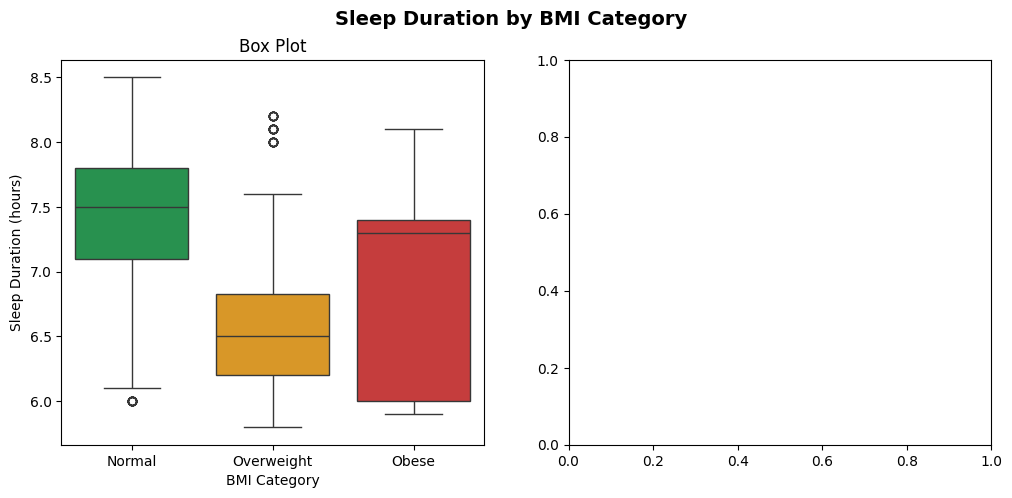

In [10]:
bmi_order = ["Normal", "Overweight", "Obese"]
palette = {"Normal": "#16A34A", "Overweight": "#F59E0B", "Obese": "#DC2626"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Sleep Duration by BMI Category", fontsize=14, fontweight="bold")

sns.boxplot(data=df, x="BMI Category", y="Sleep Duration",
            order=bmi_order, palette=palette, ax=axes[0])
axes[0].set_title("Box Plot")
axes[0].set_xlabel("BMI Category")
axes[0].set_ylabel("Sleep Duration (hours)")

Multivariate Analysis: Correlations Within BMI Groups

 Normal (n=216) 
                         Corr w/ Sleep Duration
Physical Activity Level                   0.290
Heart Rate                               -0.651
Stress Level                             -0.797
Daily Steps                               0.109

 Overweight (n=148) 
                         Corr w/ Sleep Duration
Physical Activity Level                   0.161
Heart Rate                               -0.517
Stress Level                             -0.839
Daily Steps                              -0.241

 Obese (n=10) 
                         Corr w/ Sleep Duration
Physical Activity Level                   0.990
Heart Rate                                0.190
Stress Level                             -0.996
Daily Steps                               0.853


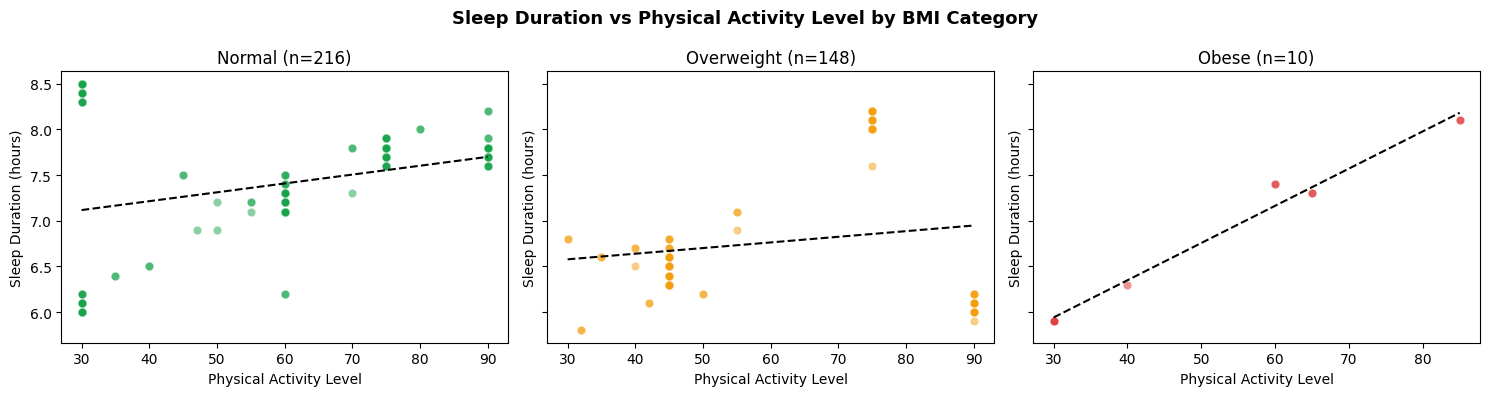

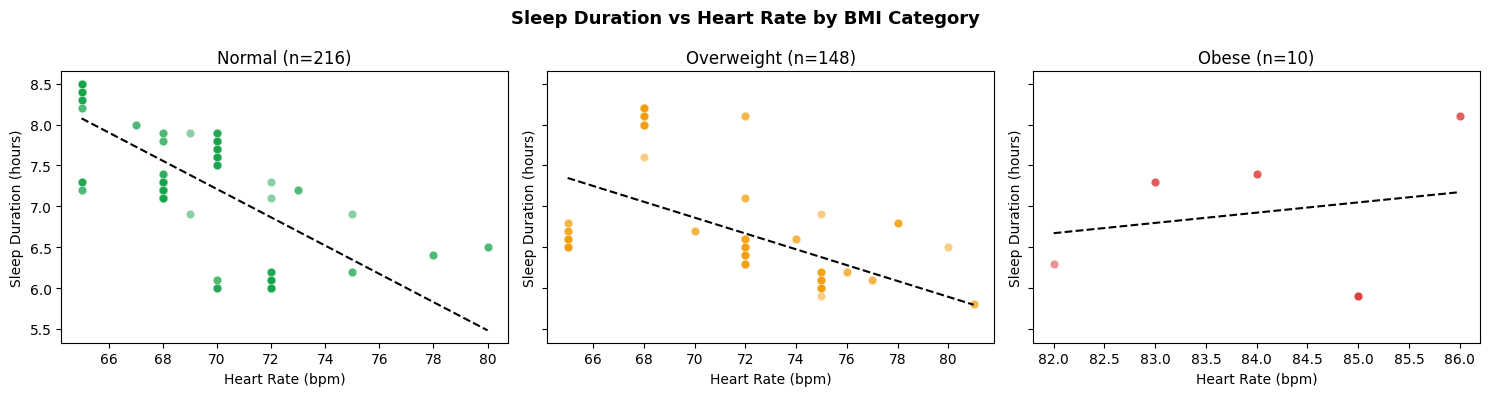

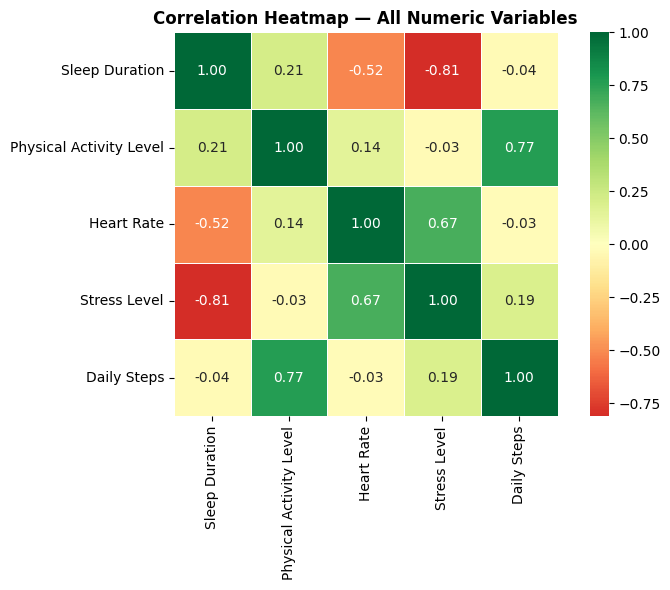

In [14]:
# Multivariate analysis
bmi_colors = {"Normal": "#16A34A", "Overweight": "#F59E0B", "Obese": "#DC2626"}
numeric_cols = ["Sleep Duration", "Physical Activity Level",
                "Heart Rate", "Stress Level", "Daily Steps"]


print("Multivariate Analysis: Correlations Within BMI Groups")


for bmi in ["Normal", "Overweight", "Obese"]:
    subset = df[df["BMI Category"] == bmi][numeric_cols]
    print(f"\n {bmi} (n={len(subset)}) ")
    corr = subset.corr()[["Sleep Duration"]].drop("Sleep Duration")
    corr.columns = ["Corr w/ Sleep Duration"]
    print(corr.round(3))

# Scatter: Sleep Duration vs Physical Activity Level
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Sleep Duration vs Physical Activity Level by BMI Category",
             fontsize=13, fontweight="bold")
for ax, bmi in zip(axes, ["Normal", "Overweight", "Obese"]):
    subset = df[df["BMI Category"] == bmi]
    ax.scatter(subset["Physical Activity Level"], subset["Sleep Duration"],
               color=bmi_colors[bmi], alpha=0.5, edgecolors="white", linewidth=0.3)
    m, b = np.polyfit(subset["Physical Activity Level"], subset["Sleep Duration"], 1)
    x_range = np.linspace(subset["Physical Activity Level"].min(),
                          subset["Physical Activity Level"].max(), 100)
    ax.plot(x_range, m * x_range + b, color="black", linewidth=1.5, linestyle="--")
    ax.set_title(f"{bmi} (n={len(subset)})")
    ax.set_xlabel("Physical Activity Level")
    ax.set_ylabel("Sleep Duration (hours)")
plt.tight_layout()
plt.show()

# Scatter: Sleep Duration vs Heart Rate
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Sleep Duration vs Heart Rate by BMI Category",
             fontsize=13, fontweight="bold")
for ax, bmi in zip(axes, ["Normal", "Overweight", "Obese"]):
    subset = df[df["BMI Category"] == bmi]
    ax.scatter(subset["Heart Rate"], subset["Sleep Duration"],
               color=bmi_colors[bmi], alpha=0.5, edgecolors="white", linewidth=0.3)
    m, b = np.polyfit(subset["Heart Rate"], subset["Sleep Duration"], 1)
    x_range = np.linspace(subset["Heart Rate"].min(), subset["Heart Rate"].max(), 100)
    ax.plot(x_range, m * x_range + b, color="black", linewidth=1.5, linestyle="--")
    ax.set_title(f"{bmi} (n={len(subset)})")
    ax.set_xlabel("Heart Rate (bpm)")
    ax.set_ylabel("Sleep Duration (hours)")
plt.tight_layout()
plt.show()

# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title("Correlation Heatmap — All Numeric Variables", fontweight="bold")
plt.tight_layout()
plt.show()